In [1]:
# Install necessary libraries if not available
!pip install -q torch torchvision matplotlib scikit-learn

# Import necessary libraries
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import os
from torchvision import models, datasets
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

In [2]:
# Define transformations for image augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ResNet input size
    transforms.RandomHorizontalFlip(),  # Augmentation
    transforms.RandomRotation(20),
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

# Define dataset path
data_path = "/kaggle/input/thermal-images-diseased-healthy-leaves-paddy/thermal images UL"  # Update if needed

# Load dataset using ImageFolder
dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Split dataset into train, validation, and test (60-20-20)
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [3]:
model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)

num_ftrs = model.fc.in_features
num_classes = 6
model.fc = nn.Linear(num_ftrs, num_classes)

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 143MB/s]


In [4]:
torch.save(model.state_dict() , "model.pth")

In [5]:
num_epochs = 30  # You can increase this for better accuracy
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_losses.append(running_loss / len(train_loader))
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    val_losses.append(val_loss / len(val_loader))
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}")

Epoch 1/30, Training Loss: 1.6963, Validation Loss: 1.7439
Epoch 2/30, Training Loss: 1.5774, Validation Loss: 1.5642
Epoch 3/30, Training Loss: 1.4987, Validation Loss: 1.4932
Epoch 4/30, Training Loss: 1.4248, Validation Loss: 1.4549
Epoch 5/30, Training Loss: 1.3530, Validation Loss: 1.4003
Epoch 6/30, Training Loss: 1.3018, Validation Loss: 1.3902
Epoch 7/30, Training Loss: 1.2712, Validation Loss: 1.3433
Epoch 8/30, Training Loss: 1.2399, Validation Loss: 1.2718
Epoch 9/30, Training Loss: 1.2149, Validation Loss: 1.2592
Epoch 10/30, Training Loss: 1.1426, Validation Loss: 1.2395
Epoch 11/30, Training Loss: 1.0915, Validation Loss: 1.2375
Epoch 12/30, Training Loss: 1.0647, Validation Loss: 1.2166
Epoch 13/30, Training Loss: 1.0537, Validation Loss: 1.1904
Epoch 14/30, Training Loss: 1.0413, Validation Loss: 1.1354
Epoch 15/30, Training Loss: 1.0273, Validation Loss: 1.1329
Epoch 16/30, Training Loss: 0.9671, Validation Loss: 1.1281
Epoch 17/30, Training Loss: 0.9314, Validation Lo

In [6]:
# Test model and compute accuracy
model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 64.84%


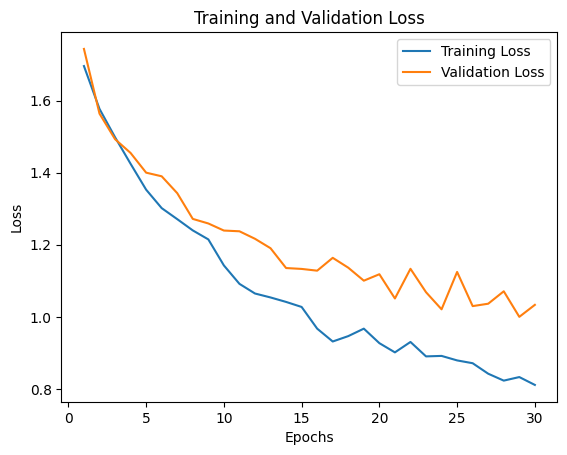

In [7]:
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig("loss_curve.png")
plt.show()

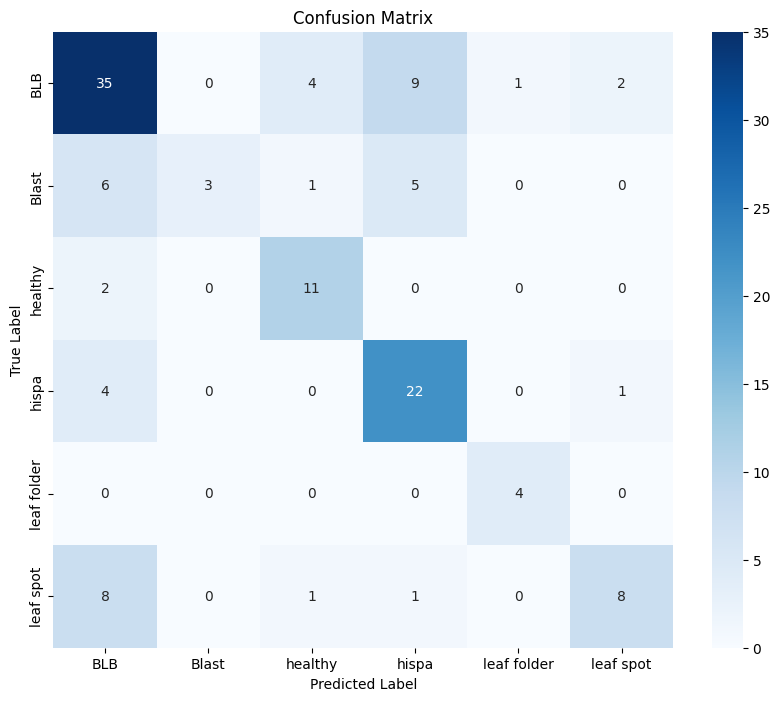

In [8]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

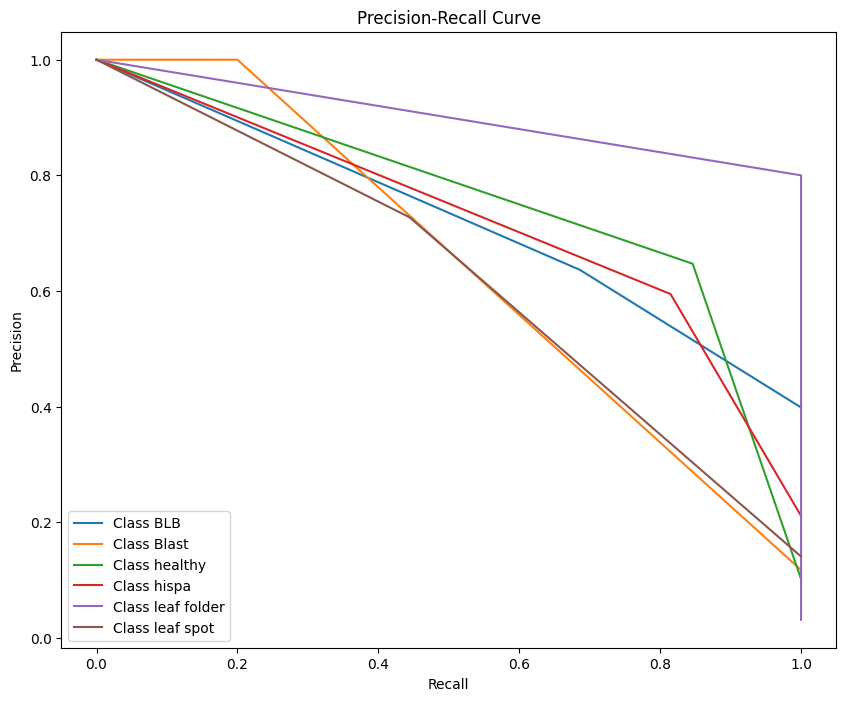

In [9]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))
y_pred_bin = label_binarize(all_preds, classes=list(range(num_classes)))

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_bin[:, i])
    plt.plot(recall, precision, label=f'Class {dataset.classes[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig("pr_curve.png")
plt.show()